# Autoregressive vs Scheduled Sampling vs Parallel Task-Decoder Plots

This notebook compares four models:

- Parallel task-decoder Transformer from `CSCI1470_Parallel_TaskDecoder_Transformer.ipynb`
- Autoregressive task-decoder Transformer without scheduled sampling
- Autoregressive task-decoder Transformer with scheduled sampling
- Mean/majority baseline

Metrics:

- Earnings: R²
- Employment: Accuracy
- Marriage: Accuracy

Plots are produced both across target age bins and as averages across the future sequence.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

OUT_DIR = Path('../results/autoregressive_comparison_plots')
OUT_DIR.mkdir(exist_ok=True)

# Change to 'val' if you want validation-set graphs instead.
PLOT_SPLIT = 'test'
print('Plot split:', PLOT_SPLIT)

Plot split: test


In [2]:
METRIC_FILES = {
    'Parallel task-decoder': Path('../results/multioutcome_transformer_lasso_outputs/task_decoder_transformer_metrics.csv'),
    'Autoregressive': Path('../results/autoregressive_task_decoder_transformer_outputs/autoregressive_task_decoder_transformer_metrics.csv'),
    'Scheduled sampling': Path('../results/scheduled_sampling_task_decoder_transformer_outputs/scheduled_sampling_task_decoder_transformer_metrics.csv'),
    'Mean/majority': Path('../results/multioutcome_transformer_lasso_outputs/mean_majority_metrics.csv'),
}

missing = [str(p) for p in METRIC_FILES.values() if not p.exists()]
if missing:
    raise FileNotFoundError('Missing metrics files:' + chr(10) + chr(10).join(missing))

def load_metrics():
    frames = []
    for label, path in METRIC_FILES.items():
        df = pd.read_csv(path)
        df['model_label'] = label
        frames.append(df)
    out = pd.concat(frames, ignore_index=True, sort=False)
    out['target_bin'] = pd.Categorical(
        out['target_bin'],
        categories=['a30_31','a32_33','a34_35','a36_37','a38_39','a40_41','a42_43','a44_45'],
        ordered=True,
    )
    out = out.sort_values(['target', 'target_bin', 'model_label', 'split']).reset_index(drop=True)
    return out

metrics = load_metrics()
metrics.head()


,model,split,target_bin,target,n,rmse,mae,r2,spearman,accuracy,f1_macro,model_label
0,AUTOREGRESSIVE_TASK_DECODER_TRANSFORMER,test,a30_31,earn,246,0.752530,0.512924,0.660134,0.838473,NaN,NaN,Autoregressive
1,AUTOREGRESSIVE_TASK_DECODER_TRANSFORMER,val,a30_31,earn,248,0.890936,0.578190,0.563111,0.758588,NaN,NaN,Autoregressive
2,MEAN_MAJORITY,test,a30_31,earn,246,1.292536,1.041081,-0.002638,NaN,NaN,NaN,Mean/majority
3,MEAN_MAJORITY,val,a30_31,earn,248,1.349113,1.094256,-0.001785,NaN,NaN,NaN,Mean/majority
4,TASK_DECODER_TRANSFORMER,test,a30_31,earn,246,0.748615,0.529638,0.663662,0.817427,NaN,NaN,Parallel task-decoder


In [3]:
plot_df = metrics[metrics['split'].eq(PLOT_SPLIT)].copy()
if plot_df.empty:
    raise ValueError(f'No rows found for split={PLOT_SPLIT!r}')

# Keep only the metrics requested for the presentation graphs.
earn_df = plot_df[plot_df['target'].eq('earn')][['model_label', 'target_bin', 'r2', 'n']].dropna(subset=['r2'])
emp_df = plot_df[plot_df['target'].eq('emp')][['model_label', 'target_bin', 'accuracy', 'n']].dropna(subset=['accuracy'])
mar_df = plot_df[plot_df['target'].eq('mar')][['model_label', 'target_bin', 'accuracy', 'n']].dropna(subset=['accuracy'])

print('Rows:', len(plot_df))
print(plot_df.groupby(['model_label', 'target']).size().unstack(fill_value=0))

Rows: 96
target                 earn  emp  mar
model_label                          
Autoregressive            8    8    8
Mean/majority             8    8    8
Parallel task-decoder     8    8    8
Scheduled sampling        8    8    8


In [4]:
MODEL_ORDER = ['Parallel task-decoder', 'Autoregressive', 'Scheduled sampling', 'Mean/majority']
COLORS = {
    'Parallel task-decoder': '#1f77b4',
    'Autoregressive': '#d62728',
    'Scheduled sampling': '#ff7f0e',
    'Mean/majority': '#7f7f7f',
}

def age_bin_label(x):
    return str(x).replace('a', '').replace('_', '-')

def plot_across_age(df, metric_col, title, ylabel, filename, zero_line=False):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for model in MODEL_ORDER:
        sub = df[df['model_label'].eq(model)].sort_values('target_bin')
        if sub.empty:
            continue
        ax.plot(
            [age_bin_label(x) for x in sub['target_bin']],
            sub[metric_col],
            marker='o',
            linewidth=2.2,
            label=model,
            color=COLORS.get(model),
        )
    if zero_line:
        ax.axhline(0, color='black', linewidth=1, alpha=0.35)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel('Target age bin')
    ax.set_ylabel(ylabel)
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    path = OUT_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print('saved:', path)

def plot_average_bar(avg_df, metric_col, title, ylabel, filename, zero_line=False):
    avg_df = avg_df.copy()
    avg_df['model_label'] = pd.Categorical(avg_df['model_label'], categories=MODEL_ORDER, ordered=True)
    avg_df = avg_df.sort_values('model_label')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(
        avg_df['model_label'].astype(str),
        avg_df[metric_col],
        color=[COLORS.get(m) for m in avg_df['model_label'].astype(str)],
        alpha=0.9,
    )
    if zero_line:
        ax.axhline(0, color='black', linewidth=1, alpha=0.35)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=25)
    ax.grid(True, axis='y', alpha=0.25)
    for i, v in enumerate(avg_df[metric_col]):
        if pd.notna(v):
            offset = 0.01 if v >= 0 else -0.03
            ax.text(i, v + offset, f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)
    fig.tight_layout()
    path = OUT_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print('saved:', path)

## Across Age Bins

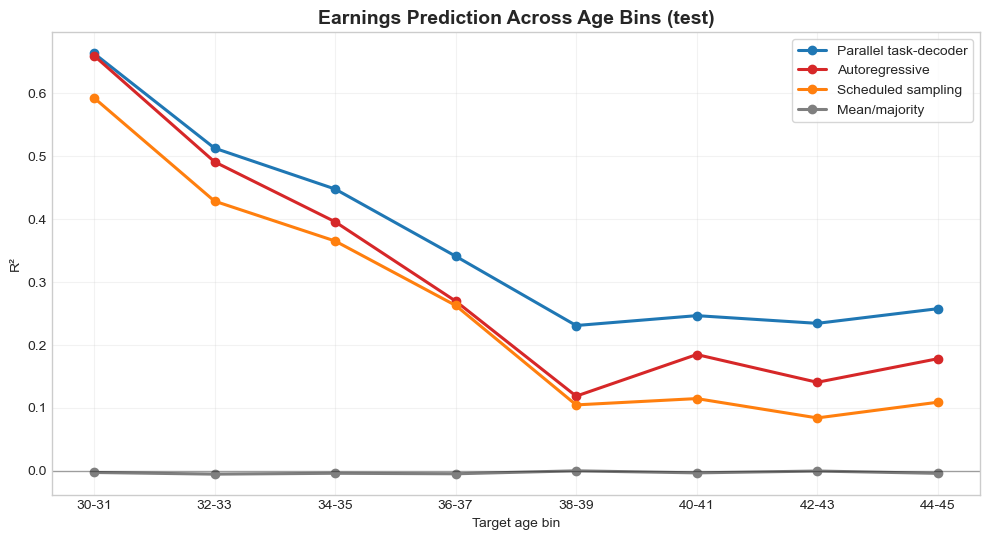

saved: autoregressive_comparison_plots/earn_r2_across_age_test.png


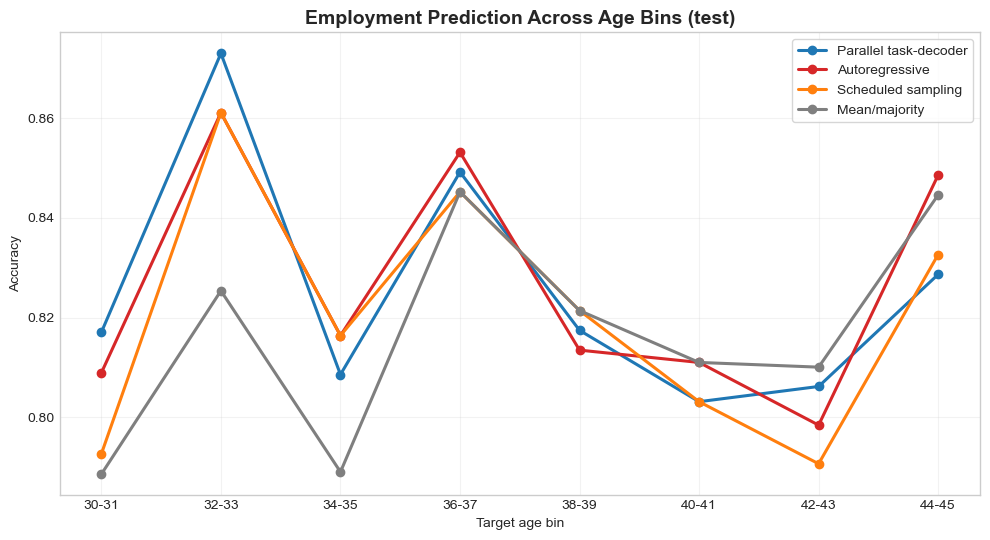

saved: autoregressive_comparison_plots/emp_accuracy_across_age_test.png


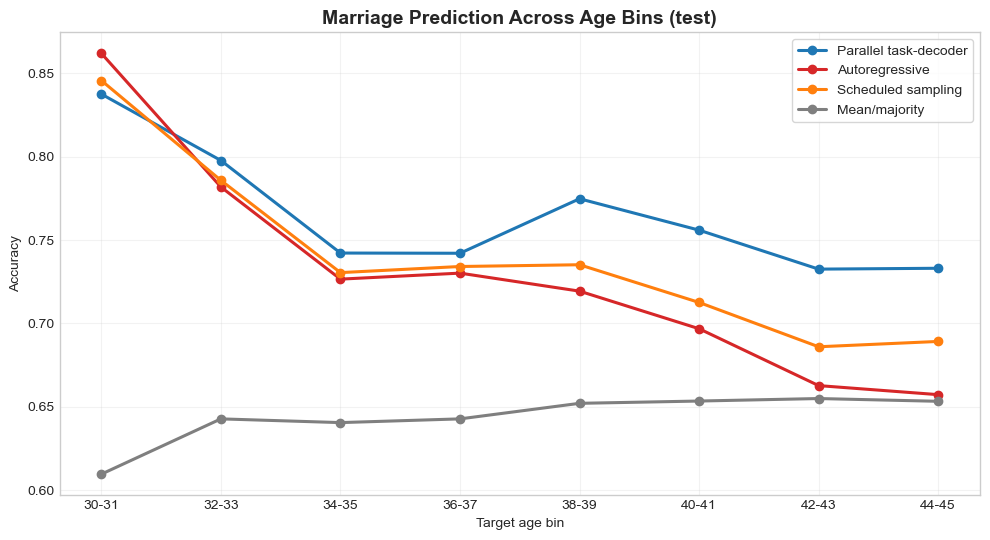

saved: autoregressive_comparison_plots/mar_accuracy_across_age_test.png


In [5]:
plot_across_age(
    earn_df, 'r2',
    f'Earnings Prediction Across Age Bins ({PLOT_SPLIT})',
    'R²',
    f'earn_r2_across_age_{PLOT_SPLIT}.png',
    zero_line=True,
)

plot_across_age(
    emp_df, 'accuracy',
    f'Employment Prediction Across Age Bins ({PLOT_SPLIT})',
    'Accuracy',
    f'emp_accuracy_across_age_{PLOT_SPLIT}.png',
)

plot_across_age(
    mar_df, 'accuracy',
    f'Marriage Prediction Across Age Bins ({PLOT_SPLIT})',
    'Accuracy',
    f'mar_accuracy_across_age_{PLOT_SPLIT}.png',
)

## Average Across Future Sequence

In [6]:
earn_avg = earn_df.groupby('model_label', as_index=False)['r2'].mean()
emp_avg = emp_df.groupby('model_label', as_index=False)['accuracy'].mean()
mar_avg = mar_df.groupby('model_label', as_index=False)['accuracy'].mean()

avg_table = (
    earn_avg.rename(columns={'r2':'earn_avg_r2'})
    .merge(emp_avg.rename(columns={'accuracy':'emp_avg_accuracy'}), on='model_label', how='outer')
    .merge(mar_avg.rename(columns={'accuracy':'mar_avg_accuracy'}), on='model_label', how='outer')
)
avg_table['model_label'] = pd.Categorical(avg_table['model_label'], categories=MODEL_ORDER, ordered=True)
avg_table = avg_table.sort_values('model_label').reset_index(drop=True)
avg_table.to_csv(OUT_DIR / f'average_metrics_{PLOT_SPLIT}.csv', index=False)
avg_table

,model_label,earn_avg_r2,emp_avg_accuracy,mar_avg_accuracy
0,Parallel task-decoder,0.366971,0.825423,0.764438
1,Autoregressive,0.304965,0.826401,0.729579
2,Scheduled sampling,0.257858,0.820423,0.739863
3,Mean/majority,-0.003022,0.816933,0.643780


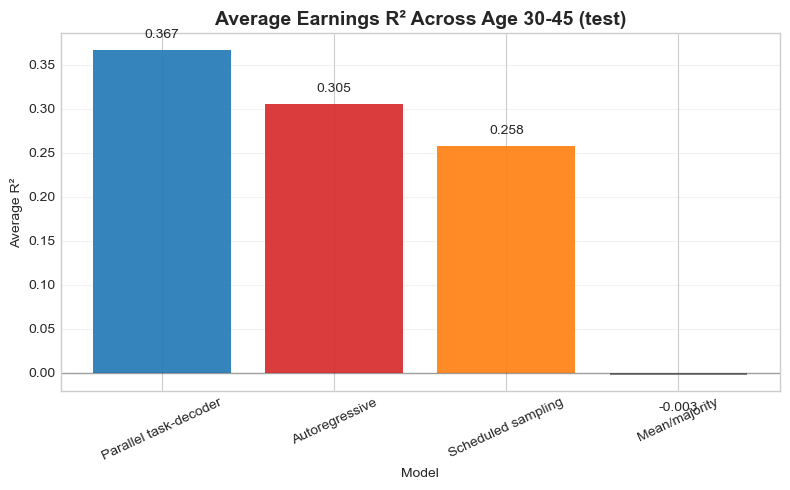

saved: autoregressive_comparison_plots/earn_avg_r2_test.png


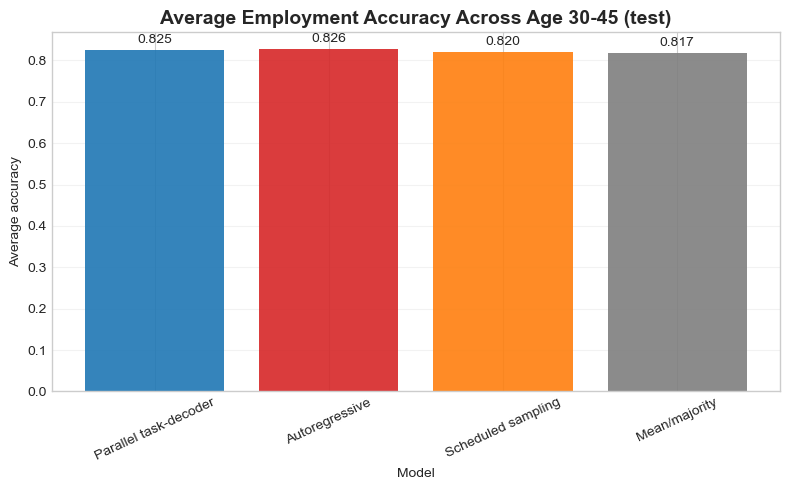

saved: autoregressive_comparison_plots/emp_avg_accuracy_test.png


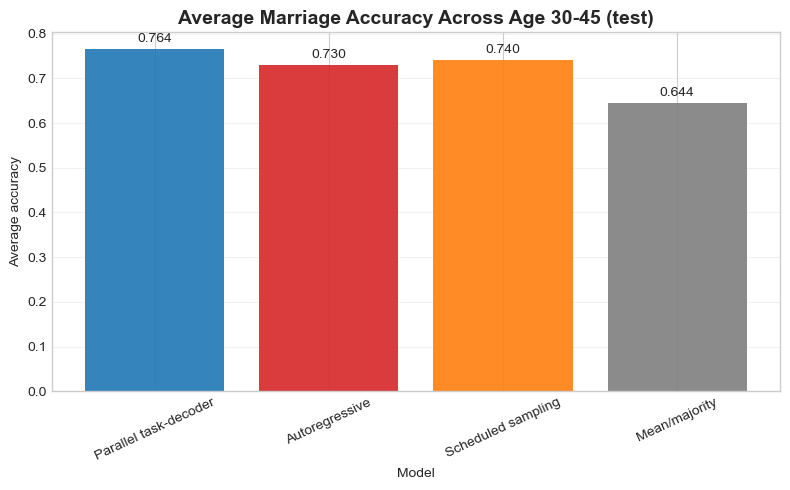

saved: autoregressive_comparison_plots/mar_avg_accuracy_test.png


In [7]:
plot_average_bar(
    earn_avg, 'r2',
    f'Average Earnings R² Across Age 30-45 ({PLOT_SPLIT})',
    'Average R²',
    f'earn_avg_r2_{PLOT_SPLIT}.png',
    zero_line=True,
)

plot_average_bar(
    emp_avg, 'accuracy',
    f'Average Employment Accuracy Across Age 30-45 ({PLOT_SPLIT})',
    'Average accuracy',
    f'emp_avg_accuracy_{PLOT_SPLIT}.png',
)

plot_average_bar(
    mar_avg, 'accuracy',
    f'Average Marriage Accuracy Across Age 30-45 ({PLOT_SPLIT})',
    'Average accuracy',
    f'mar_avg_accuracy_{PLOT_SPLIT}.png',
)

## Combined Summary Figure

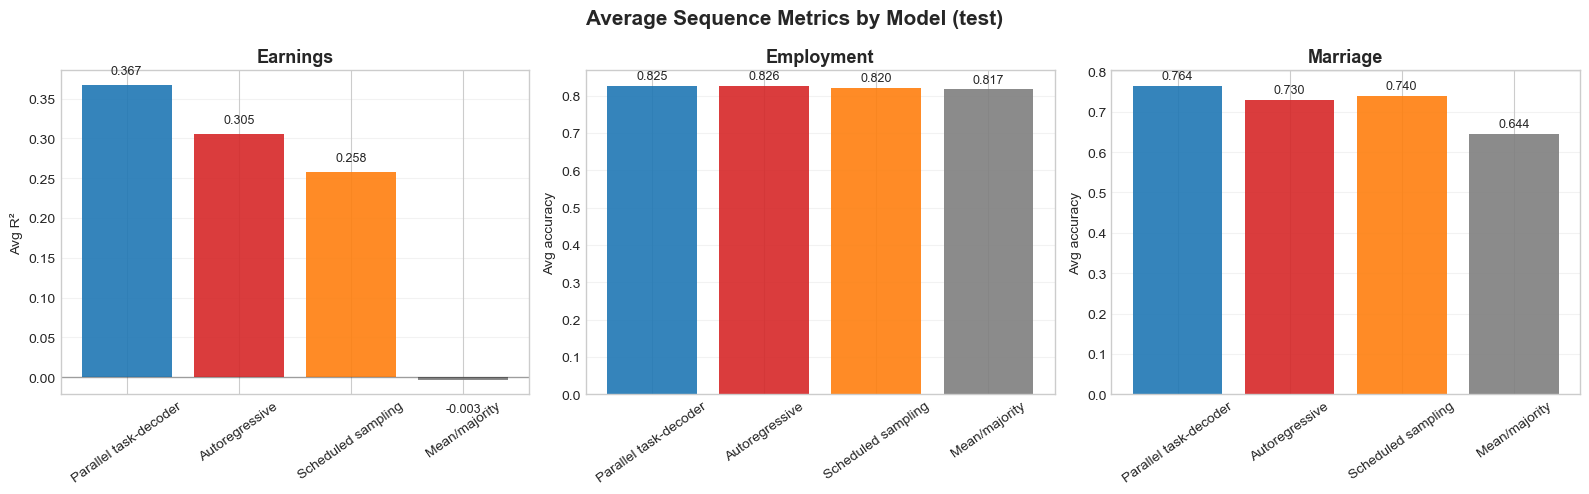

saved: autoregressive_comparison_plots/combined_average_metrics_test.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
summary_specs = [
    (earn_avg, 'r2', 'Earnings', 'Avg R²'),
    (emp_avg, 'accuracy', 'Employment', 'Avg accuracy'),
    (mar_avg, 'accuracy', 'Marriage', 'Avg accuracy'),
]
for ax, (df, metric_col, title, ylabel) in zip(axes, summary_specs):
    df = df.copy()
    df['model_label'] = pd.Categorical(df['model_label'], categories=MODEL_ORDER, ordered=True)
    df = df.sort_values('model_label')
    ax.bar(
        df['model_label'].astype(str),
        df[metric_col],
        color=[COLORS.get(m) for m in df['model_label'].astype(str)],
        alpha=0.9,
    )
    if metric_col == 'r2':
        ax.axhline(0, color='black', linewidth=1, alpha=0.35)
    ax.set_title(title, fontsize=13, weight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(True, axis='y', alpha=0.25)
    for i, v in enumerate(df[metric_col]):
        if pd.notna(v):
            offset = 0.01 if v >= 0 else -0.03
            ax.text(i, v + offset, f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
fig.suptitle(f'Average Sequence Metrics by Model ({PLOT_SPLIT})', fontsize=15, weight='bold')
fig.tight_layout()
path = OUT_DIR / f'combined_average_metrics_{PLOT_SPLIT}.png'
fig.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print('saved:', path)